# Real-vs-calculated IMF comparison

This notebook mirrors `gd_imrf.ipynb` and compares clean-reference IMFs to calculated IMFs under two observation regimes. The clean-reference IMF is computed from the clean signal using the same contrast as the calculated decomposition in each grid.

## Setup

The signal, observation generator, window schedule, and robust gradient-descent definitions are copied from `gd_imrf.ipynb`.

In [60]:
import os
import time
from concurrent.futures import ThreadPoolExecutor
from numpy.lib.stride_tricks import sliding_window_view

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


rng = np.random.default_rng(42)

SQRT_2 = np.sqrt(2.0)
SQRT_2_OVER_PI = np.sqrt(2.0 / np.pi)
DEFAULT_MAX_WORKERS = 12

plt.rcParams.update({
    "figure.figsize": (11, 4),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

DEFAULT_MAX_WORKERS


12

## Signal, observation, and window schedule

The contaminated observation below is exactly the `p = 0.2` setup from `gd_imrf.ipynb`. The no-contamination observation is created later with the same seed, Gaussian scale, and contamination scale, but with `contamination_prob = 0.0`.

In [61]:
def odd_ceiling(value):
    size = int(np.ceil(value))
    if size % 2 == 0:
        size += 1
    return max(1, size)


def nearest_odd(value):
    rounded = int(np.round(value))
    if rounded % 2 == 1:
        return max(1, rounded)

    lower = max(1, rounded - 1)
    upper = rounded + 1
    if abs(value - lower) <= abs(upper - value):
        return lower
    return upper


def make_window_schedule(n, factor=np.sqrt(2.0), min_window_size=31):
    if n <= 0:
        raise ValueError("n must be positive")
    if factor <= 1:
        raise ValueError("factor must be larger than 1")

    first = odd_ceiling(n / 2)
    if first > n:
        first = n if n % 2 == 1 else n - 1

    min_size = nearest_odd(min_window_size)
    if min_size > first:
        return [first]

    sizes = [first]
    current = first

    while current > min_size:
        candidate = nearest_odd(current / factor)
        candidate = min(candidate, current - 2)
        if candidate % 2 == 0:
            candidate -= 1
        if candidate < min_size:
            candidate = min_size

        sizes.append(candidate)
        current = candidate

    return sizes


def gen_signal(t):
    slow = 0.6 * np.sin(2 * np.pi * t)
    medium = 0.25 * np.sin(12 * np.pi * t)
    bump = 0.8 * np.exp(-((t - 0.55) ** 2) / (2 * 0.015 ** 2))
    trend = 0.5 * (t - 0.5)

    x = slow + medium + bump + trend

    components = {
        "slow": slow,
        "medium": medium,
        "bump": bump,
        "trend": trend,
    }
    return x, components


def generate_observation(
    x,
    sigma=0.1,
    contamination_prob=0.05,
    contamination_scale=0.1,
    centered_contamination=False,
    rng=None,
):
    if rng is None:
        rng = np.random.default_rng()

    gaussian_noise = rng.normal(loc=0.0, scale=sigma, size=len(x))
    contamination_mask = rng.random(len(x)) < contamination_prob
    exponential_noise = rng.exponential(scale=contamination_scale, size=len(x))

    if centered_contamination:
        exponential_noise = exponential_noise - contamination_scale

    contamination = contamination_mask * exponential_noise

    sign = rng.choice([-1, 1], size=len(x))
    contamination *= sign

    y = x + gaussian_noise + contamination

    return y, {
        "gaussian_noise": gaussian_noise,
        "contamination": contamination,
        "contamination_mask": contamination_mask,
    }


n = 1000
t = np.linspace(0.0, 1.0, n)
sigma = 0.2
H = 2 * sigma

window_sizes = make_window_schedule(n, factor=np.sqrt(2.0), min_window_size=31)
x_clean, true_components = gen_signal(t)
y_observed, noise_info = generate_observation(
    x_clean,
    sigma=sigma,
    contamination_prob=0.2,
    contamination_scale=0.2,
    rng=np.random.default_rng(777),
)

assert window_sizes[0] == 501
assert all(size % 2 == 1 for size in window_sizes)
assert all(left > right for left, right in zip(window_sizes, window_sizes[1:]))
assert min(window_sizes) >= 31

window_schedule_df = pd.DataFrame({
    "stage": np.arange(1, len(window_sizes) + 1),
    "window_size": window_sizes,
    "radius": [size // 2 for size in window_sizes],
    "relative_width": np.array(window_sizes) / n,
})

window_schedule_df


,stage,window_size,radius,relative_width
0,1,501,250,0.501
1,2,355,177,0.355
2,3,251,125,0.251
3,4,177,88,0.177
4,5,125,62,0.125
5,6,89,44,0.089
6,7,63,31,0.063
7,8,45,22,0.045
8,9,31,15,0.031


## Kernel, robust contrast, and lookup grid

The linear IMF uses the same Epanechnikov window weights. The robust IMF uses the same smoothed absolute contrast and lookup-grid score approximation as `gd_imrf.ipynb`.

In [62]:
def epanechnikov_weights(window_size):
    if window_size % 2 == 0:
        raise ValueError("window_size must be odd")

    radius = window_size // 2
    if radius == 0:
        return np.array([1.0])

    offsets = np.arange(-radius, radius + 1)
    u = offsets / radius
    weights = 0.75 * np.maximum(0.0, 1.0 - np.abs(u)) ** 2
    return weights / weights.sum()


def erf_approx(x):
    x = np.asarray(x, dtype=float)
    sign = np.sign(x)
    ax = np.abs(x)

    p = 0.3275911
    a1 = 0.254829592
    a2 = -0.284496736
    a3 = 1.421413741
    a4 = -1.453152027
    a5 = 1.061405429

    z = 1.0 / (1.0 + p * ax)
    poly = (((((a5 * z + a4) * z + a3) * z + a2) * z + a1) * z)
    return sign * (1.0 - poly * np.exp(-(ax ** 2)))


def exact_score(residual, H):
    if H <= 0:
        raise ValueError("H must be positive")
    return erf_approx(np.asarray(residual, dtype=float) / (SQRT_2 * H))


def exact_exp(residual, H):
    if H <= 0:
        raise ValueError("H must be positive")
    z = np.asarray(residual, dtype=float) / H
    return np.exp(-0.5 * z ** 2)


def smooth_abs_rho_exact(residual, H):
    residual = np.asarray(residual, dtype=float)
    return residual * exact_score(residual, H) + SQRT_2_OVER_PI * H * exact_exp(residual, H)


def make_lookup_grid(zmax=8.0, num=4097):
    if zmax <= 0:
        raise ValueError("zmax must be positive")
    if num < 3:
        raise ValueError("num must be at least 3")

    z_grid = np.linspace(-zmax, zmax, num)
    return {
        "z": z_grid,
        "score": erf_approx(z_grid / SQRT_2),
        "exp": np.exp(-0.5 * z_grid ** 2),
        "zmax": float(zmax),
        "num": int(num),
    }


def _interp_like(values, x_grid, y_grid, left, right):
    values = np.asarray(values, dtype=float)
    flat = np.interp(values.ravel(), x_grid, y_grid, left=left, right=right)
    return flat.reshape(values.shape)


def lookup_score(residual, H, grid):
    if H <= 0:
        raise ValueError("H must be positive")
    z = np.asarray(residual, dtype=float) / H
    return _interp_like(z, grid["z"], grid["score"], left=-1.0, right=1.0)


def lookup_exp(residual, H, grid):
    if H <= 0:
        raise ValueError("H must be positive")
    z = np.asarray(residual, dtype=float) / H
    return _interp_like(z, grid["z"], grid["exp"], left=0.0, right=0.0)


def smooth_abs_rho_lookup(residual, H, grid):
    residual = np.asarray(residual, dtype=float)
    return residual * lookup_score(residual, H, grid) + SQRT_2_OVER_PI * H * lookup_exp(residual, H, grid)


lookup_grid = make_lookup_grid(zmax=8.0, num=4097)

for size in window_sizes:
    weights = epanechnikov_weights(size)
    assert np.all(weights >= 0)
    assert np.isclose(weights.sum(), 1.0)

z_validation = np.linspace(-lookup_grid["zmax"], lookup_grid["zmax"], 20001)
residual_validation = z_validation * H

score_max_error = np.max(np.abs(
    lookup_score(residual_validation, H, lookup_grid)
    - exact_score(residual_validation, H)
))
exp_max_error = np.max(np.abs(
    lookup_exp(residual_validation, H, lookup_grid)
    - exact_exp(residual_validation, H)
))
tail_exp_at_zmax = np.exp(-0.5 * lookup_grid["zmax"] ** 2)

assert score_max_error < 5e-4
assert exp_max_error < 5e-4
assert tail_exp_at_zmax < 1e-12

pd.DataFrame([
    {"quantity": "score max abs error", "value": score_max_error},
    {"quantity": "exponent max abs error", "value": exp_max_error},
    {"quantity": "exp(-zmax^2 / 2)", "value": tail_exp_at_zmax},
])


,quantity,value
0,score max abs error,9.226423e-07
1,exponent max abs error,1.906223e-06
2,exp(-zmax^2 / 2),1.266417e-14


## IMF implementations

The robust gradient-descent implementation is reused from `gd_imrf.ipynb`. The linear implementation is the weighted-mean solution for the quadratic contrast `rho(x) = x^2 / 2`, with the same residual update convention.

In [63]:
def robust_gd_fit_windows(
    windows,
    weights,
    H,
    grid=None,
    max_iter=60,
    tol=1e-6,
    return_trace=False,
):
    windows = np.asarray(windows, dtype=float)
    weights = np.asarray(weights, dtype=float)

    if windows.ndim != 2:
        raise ValueError("windows must be a 2D array")
    if H <= 0:
        raise ValueError("H must be positive")
    if len(windows) == 0:
        empty = np.array([], dtype=float)
        return (empty, empty) if return_trace else empty

    if grid is None:
        grid = lookup_grid

    weights = weights / weights.sum()
    row_weights = weights.reshape(1, -1)

    x = np.median(windows, axis=1)
    lower = windows.min(axis=1)
    upper = windows.max(axis=1)
    trace = []

    step = 0.95 * H / SQRT_2_OVER_PI

    for _ in range(max_iter):
        local_score = np.sum(
            row_weights * lookup_score(windows - x[:, None], H, grid),
            axis=1,
        )
        x_next = np.clip(x + step * local_score, lower, upper)
        max_delta = float(np.max(np.abs(x_next - x)))
        trace.append(max_delta)
        x = x_next

        if max_delta <= tol * (1.0 + float(np.max(np.abs(x)))):
            break

    if return_trace:
        return x, np.array(trace, dtype=float)
    return x


def _robust_filter_chunk(args):
    start, stop, windows, weights, H, grid, max_iter, tol = args
    values, trace = robust_gd_fit_windows(
        windows[start:stop],
        weights,
        H,
        grid=grid,
        max_iter=max_iter,
        tol=tol,
        return_trace=True,
    )
    return start, values, trace


def combine_traces(traces):
    if not traces:
        return np.array([], dtype=float)

    max_len = max(len(trace) for trace in traces)
    combined = np.zeros(max_len, dtype=float)

    for i in range(max_len):
        combined[i] = max(
            (trace[i] if i < len(trace) else 0.0)
            for trace in traces
        )

    return combined


def local_robust_gd_filter(
    y,
    window_size,
    H,
    grid=None,
    boundary="wrap",
    max_iter=60,
    tol=1e-6,
    max_workers=1,
    chunk_size=None,
    return_trace=False,
):
    if window_size % 2 == 0:
        raise ValueError("window_size must be odd")
    if grid is None:
        grid = lookup_grid

    y = np.asarray(y, dtype=float)
    radius = window_size // 2
    weights = epanechnikov_weights(window_size)
    y_padded = np.pad(y, pad_width=radius, mode=boundary)
    windows = sliding_window_view(y_padded, window_size)

    n_obs = len(y)
    max_workers = max(1, int(max_workers or 1))
    if chunk_size is None:
        chunk_size = n_obs if max_workers == 1 else max(64, int(np.ceil(n_obs / max_workers)))

    ranges = [
        (start, min(start + chunk_size, n_obs))
        for start in range(0, n_obs, chunk_size)
    ]

    if max_workers == 1 or len(ranges) == 1:
        values, trace = robust_gd_fit_windows(
            windows,
            weights,
            H,
            grid=grid,
            max_iter=max_iter,
            tol=tol,
            return_trace=True,
        )
        return (values, trace) if return_trace else values

    out = np.empty(n_obs, dtype=float)
    traces = []
    args = [
        (start, stop, windows, weights, H, grid, max_iter, tol)
        for start, stop in ranges
    ]

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        for start, values, trace in executor.map(_robust_filter_chunk, args):
            out[start:start + len(values)] = values
            traces.append(trace)

    trace = combine_traces(traces)
    return (out, trace) if return_trace else out


def robust_gd_imf_with_history(
    y,
    window_sizes,
    H,
    grid=None,
    boundary="wrap",
    max_iter=60,
    tol=1e-6,
    max_workers=1,
):
    residual = np.asarray(y, dtype=float).copy()
    residuals = [residual.copy()]
    imfs = []
    stage_info = []

    start_time = time.perf_counter()
    for stage_index, window_size in enumerate(window_sizes, start=1):
        imf, trace = local_robust_gd_filter(
            residual,
            window_size,
            H,
            grid=grid,
            boundary=boundary,
            max_iter=max_iter,
            tol=tol,
            max_workers=max_workers,
            return_trace=True,
        )
        imfs.append(imf)
        residual = residual - imf
        residuals.append(residual.copy())
        stage_info.append({
            "stage": stage_index,
            "window_size": window_size,
            "iterations": len(trace),
            "final_max_delta": float(trace[-1]) if len(trace) else np.nan,
            "trace": trace,
        })

    imfs = np.array(imfs)
    residuals = np.array(residuals)

    return {
        "imfs": imfs,
        "residual": residual,
        "residuals": residuals,
        "reconstruction": imfs.sum(axis=0) + residual,
        "stage_info": stage_info,
        "elapsed_seconds": time.perf_counter() - start_time,
        "H": float(H),
    }


In [64]:
def local_linear_filter(y, window_size, boundary="wrap"):
    if window_size % 2 == 0:
        raise ValueError("window_size must be odd")

    y = np.asarray(y, dtype=float)
    radius = window_size // 2
    weights = epanechnikov_weights(window_size)
    y_padded = np.pad(y, pad_width=radius, mode=boundary)
    windows = sliding_window_view(y_padded, window_size)
    return windows @ weights


def linear_imf_with_history(y, window_sizes, boundary="wrap"):
    residual = np.asarray(y, dtype=float).copy()
    residuals = [residual.copy()]
    imfs = []
    stage_info = []

    start_time = time.perf_counter()
    for stage_index, window_size in enumerate(window_sizes, start=1):
        imf = local_linear_filter(
            residual,
            window_size,
            boundary=boundary,
        )
        imfs.append(imf)
        residual = residual - imf
        residuals.append(residual.copy())
        stage_info.append({
            "stage": stage_index,
            "window_size": window_size,
            "iterations": 1,
            "final_max_delta": np.nan,
            "trace": np.array([], dtype=float),
        })

    imfs = np.array(imfs)
    residuals = np.array(residuals)

    return {
        "imfs": imfs,
        "residual": residual,
        "residuals": residuals,
        "reconstruction": imfs.sum(axis=0) + residual,
        "stage_info": stage_info,
        "elapsed_seconds": time.perf_counter() - start_time,
    }

## Run decompositions

`a = sqrt(2)` is the rate used to decrease the window radius. The scaled-error panels multiply each component error by `sqrt(a)`.

In [65]:
a = np.sqrt(2.0)
error_scale = np.sqrt(a)

# No-contamination observation: same signal, sigma, scale, and RNG seed, with p = 0.
y_no_contamination, no_contamination_info = generate_observation(
    x_clean,
    sigma=sigma,
    contamination_prob=0.0,
    contamination_scale=0.2,
    rng=np.random.default_rng(777),
)

# Recreate the contaminated observation once to lock the intended setup.
y_observed_check, noise_info_check = generate_observation(
    x_clean,
    sigma=sigma,
    contamination_prob=0.2,
    contamination_scale=0.2,
    rng=np.random.default_rng(777),
)
assert np.array_equal(y_observed, y_observed_check)
assert np.array_equal(noise_info["contamination_mask"], noise_info_check["contamination_mask"])
assert not np.any(no_contamination_info["contamination_mask"])

real_linear = linear_imf_with_history(x_clean, window_sizes)
calculated_linear = linear_imf_with_history(y_no_contamination, window_sizes)

real_robust = robust_gd_imf_with_history(
    x_clean,
    window_sizes,
    H=H,
    grid=lookup_grid,
    max_iter=60,
    tol=1e-6,
    max_workers=DEFAULT_MAX_WORKERS,
)
calculated_robust = robust_gd_imf_with_history(
    y_observed,
    window_sizes,
    H=H,
    grid=lookup_grid,
    max_iter=60,
    tol=1e-6,
    max_workers=DEFAULT_MAX_WORKERS,
)


def reconstruction_max_abs_error(signal, result):
    return float(np.max(np.abs(np.asarray(signal) - result["reconstruction"])))


reconstruction_summary = pd.DataFrame([
    {
        "case": "clean signal",
        "method": "linear",
        "max_reconstruction_error": reconstruction_max_abs_error(x_clean, real_linear),
        "elapsed_seconds": real_linear["elapsed_seconds"],
    },
    {
        "case": "no contamination observation",
        "method": "linear",
        "max_reconstruction_error": reconstruction_max_abs_error(y_no_contamination, calculated_linear),
        "elapsed_seconds": calculated_linear["elapsed_seconds"],
    },
    {
        "case": "clean signal",
        "method": "robust GD",
        "max_reconstruction_error": reconstruction_max_abs_error(x_clean, real_robust),
        "elapsed_seconds": real_robust["elapsed_seconds"],
    },
    {
        "case": "p = 0.2 observation",
        "method": "robust GD",
        "max_reconstruction_error": reconstruction_max_abs_error(y_observed, calculated_robust),
        "elapsed_seconds": calculated_robust["elapsed_seconds"],
    },
])

assert reconstruction_summary["max_reconstruction_error"].max() < 1e-10

observation_summary = pd.DataFrame([
    {
        "observation": "no contamination",
        "contamination_probability": 0.0,
        "realized_contamination_fraction": no_contamination_info["contamination_mask"].mean(),
        "max_abs_contamination": np.max(np.abs(no_contamination_info["contamination"])),
    },
    {
        "observation": "p = 0.2",
        "contamination_probability": 0.2,
        "realized_contamination_fraction": noise_info["contamination_mask"].mean(),
        "max_abs_contamination": np.max(np.abs(noise_info["contamination"])),
    },
])

print("Reconstruction checks")
display(reconstruction_summary)

print("Observation checks")
display(observation_summary)

Reconstruction checks


,case,method,max_reconstruction_error,elapsed_seconds
0,clean signal,linear,2.220446e-16,0.001627
1,no contamination observation,linear,2.220446e-16,0.001457
2,clean signal,robust GD,2.220446e-16,0.052020
3,p = 0.2 observation,robust GD,2.220446e-16,0.099067


Observation checks


,observation,contamination_probability,realized_contamination_fraction,max_abs_contamination
0,no contamination,0.0,0.000,0.000000
1,p = 0.2,0.2,0.175,1.347706


## Observations

The top panel is the Gaussian-noise-only observation. The bottom panel is the contaminated observation used by the robust comparison.

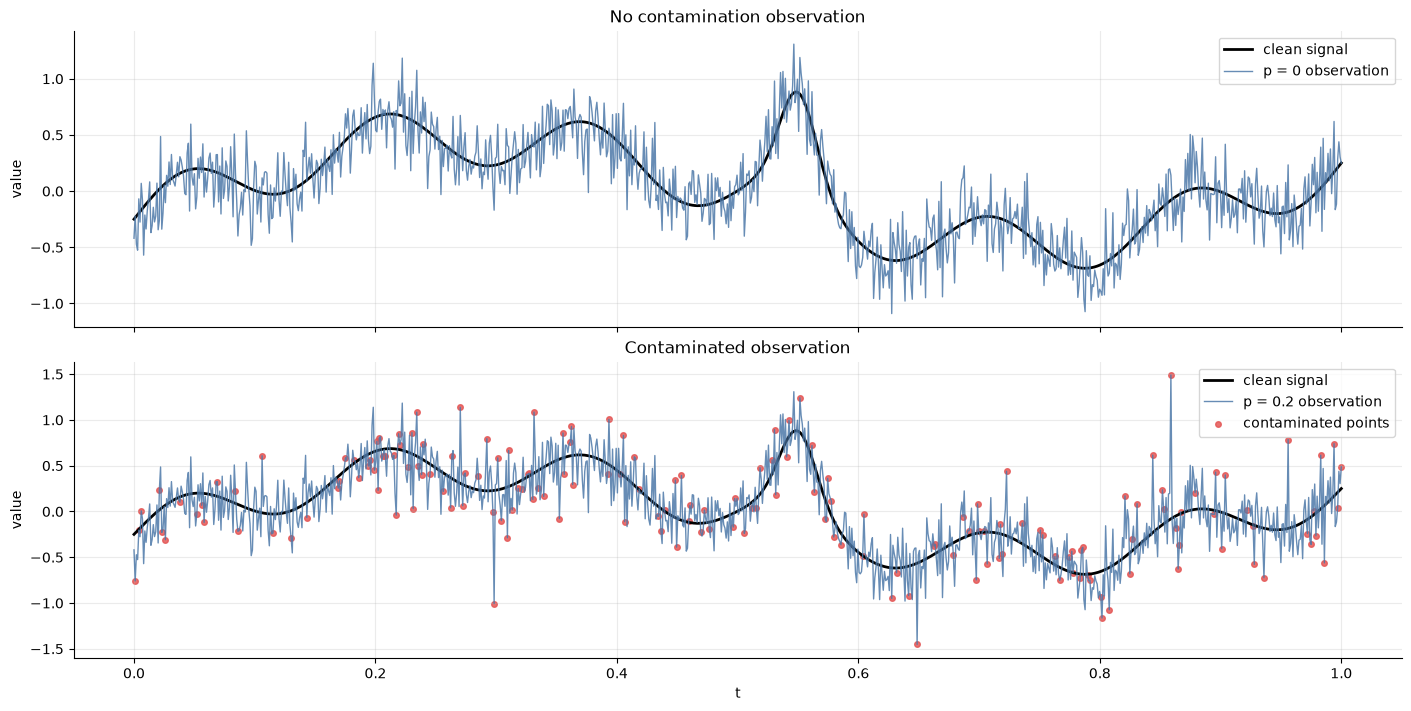

In [66]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True, constrained_layout=True)

axes[0].plot(t, x_clean, color="black", linewidth=2.0, label="clean signal")
axes[0].plot(t, y_no_contamination, color="#4C78A8", linewidth=1.0, alpha=0.85, label="p = 0 observation")
axes[0].set_title("No contamination observation")
axes[0].set_ylabel("value")
axes[0].legend(loc="upper right")

mask = noise_info["contamination_mask"]
axes[1].plot(t, x_clean, color="black", linewidth=2.0, label="clean signal")
axes[1].plot(t, y_observed, color="#4C78A8", linewidth=1.0, alpha=0.85, label="p = 0.2 observation")
axes[1].scatter(
    t[mask],
    y_observed[mask],
    s=16,
    color="#E45756",
    alpha=0.85,
    label="contaminated points",
)
axes[1].set_title("Contaminated observation")
axes[1].set_xlabel("t")
axes[1].set_ylabel("value")
axes[1].legend(loc="upper right")

plt.show()

## Component error summary

Errors are computed as `calculated_imf - real_imf` for each IMF stage.

In [67]:
def component_error_frame(case_name, real_result, calculated_result):
    rows = []
    for stage_index, window_size in enumerate(window_sizes, start=1):
        real_imf = real_result["imfs"][stage_index - 1]
        calculated_imf = calculated_result["imfs"][stage_index - 1]
        error = calculated_imf - real_imf
        scaled_error = error * error_scale
        rows.append({
            "case": case_name,
            "stage": stage_index,
            "window_size": window_size,
            "error_mean": np.mean(error),
            "error_mae": np.mean(np.abs(error)),
            "error_rmse": np.sqrt(np.mean(error ** 2)),
            "scaled_error_rmse": np.sqrt(np.mean(scaled_error ** 2)),
            "error_max_abs": np.max(np.abs(error)),
        })
    return pd.DataFrame(rows)


error_summary = pd.concat(
    [
        component_error_frame("no contamination / linear", real_linear, calculated_linear),
        component_error_frame("p = 0.2 / robust", real_robust, calculated_robust),
    ],
    ignore_index=True,
)

error_summary

,case,stage,window_size,error_mean,error_mae,error_rmse,scaled_error_rmse,error_max_abs
0,no contamination / linear,1,501,-2.784483e-03,0.010927,0.012040,0.014318,0.022712
1,no contamination / linear,2,355,-6.661338e-19,0.004295,0.005293,0.006295,0.010921
2,no contamination / linear,3,251,9.436896e-19,0.004078,0.004963,0.005903,0.011185
3,no contamination / linear,4,177,-1.332268e-18,0.004000,0.005170,0.006148,0.016082
4,no contamination / linear,5,125,-1.859624e-18,0.005456,0.006697,0.007964,0.021303
5,no contamination / linear,6,89,1.026956e-18,0.007627,0.009464,0.011255,0.027050
6,no contamination / linear,7,63,8.326673e-20,0.009966,0.012480,0.014841,0.035165
7,no contamination / linear,8,45,1.665335e-19,0.010443,0.013264,0.015774,0.044231
8,no contamination / linear,9,31,-1.387779e-20,0.013078,0.016586,0.019725,0.055912
9,p = 0.2 / robust,1,501,-6.542515e-03,0.014930,0.016778,0.019952,0.028808


## Comparison grids

Each row is one IMF stage. Within each grid, both IMF columns share one min/max y-axis range, the error column has its own min/max range, and the scaled-error column has its own min/max range.

In [68]:
def min_max_limits(*arrays, pad_fraction=0.06, min_span=1e-6):
    values = np.concatenate([np.ravel(np.asarray(array, dtype=float)) for array in arrays])
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return (-1.0, 1.0)

    low = float(np.min(values))
    high = float(np.max(values))
    if high - low < min_span:
        center = 0.5 * (low + high)
        return (center - 0.5, center + 0.5)

    pad = pad_fraction * (high - low)
    return (low - pad, high + pad)


def comparison_column_limits(real_result, calculated_result):
    real_imfs = np.asarray(real_result["imfs"], dtype=float)
    calculated_imfs = np.asarray(calculated_result["imfs"], dtype=float)
    errors = calculated_imfs - real_imfs
    scaled_errors = errors * error_scale

    return {
        "imf": min_max_limits(real_imfs, calculated_imfs),
        "error": min_max_limits(errors),
        "scaled_error": min_max_limits(scaled_errors),
    }


def plot_imf_comparison_grid(real_result, calculated_result, calculated_label, title):
    n_stages = len(window_sizes)
    limits = comparison_column_limits(real_result, calculated_result)

    fig, axes = plt.subplots(
        n_stages,
        4,
        figsize=(18, 2.25 * n_stages),
        sharex=True,
        constrained_layout=True,
    )

    column_titles = ["Real IMF", calculated_label, "Error", "Error * sqrt(a)"]
    for col, column_title in enumerate(column_titles):
        axes[0, col].set_title(column_title, fontsize=12)

    for row, window_size in enumerate(window_sizes):
        real_imf = real_result["imfs"][row]
        calculated_imf = calculated_result["imfs"][row]
        error = calculated_imf - real_imf
        scaled_error = error * error_scale

        axes[row, 0].plot(t, real_imf, color="black", linewidth=1.25)
        axes[row, 0].set_ylim(*limits["imf"])
        axes[row, 0].set_ylabel(f"IMF {row + 1}\nwindow={window_size}")

        axes[row, 1].plot(t, calculated_imf, color="#4C78A8", linewidth=1.1)
        axes[row, 1].set_ylim(*limits["imf"])

        axes[row, 2].axhline(0.0, color="#666666", linewidth=0.8, alpha=0.65)
        axes[row, 2].plot(t, error, color="#E45756", linewidth=1.0)
        axes[row, 2].set_ylim(*limits["error"])

        axes[row, 3].axhline(0.0, color="#666666", linewidth=0.8, alpha=0.65)
        axes[row, 3].plot(t, scaled_error, color="#54A24B", linewidth=1.0)
        axes[row, 3].set_ylim(*limits["scaled_error"])

        for col in range(4):
            axes[row, col].tick_params(axis="both", labelsize=8)
            axes[row, col].margins(x=0.0)

    for ax in axes[-1, :]:
        ax.set_xlabel("t")

    fig.suptitle(title, fontsize=15)
    return fig, axes

def fit_line(x, y):
    slope, intercept = np.polyfit(np.asarray(x, dtype=float), np.asarray(y, dtype=float), deg=1)
    return float(slope), float(intercept)


def plot_error_trend(case_name, title, min_stage=1):
    case_df = error_summary.loc[
        (error_summary["case"] == case_name)
        & (error_summary["stage"] >= min_stage)
    ].copy()
    if case_df.empty:
        raise ValueError(f"No rows found for case: {case_name} with min_stage={min_stage}")

    x = case_df["stage"].to_numpy(dtype=float)
    x_fit = np.linspace(x.min(), x.max(), 200)

    metrics = [
        ("error_rmse", "RMSE(error)", "#E45756"),
        ("scaled_error_rmse", "RMSE(error * sqrt(a))", "#54A24B"),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True, constrained_layout=True)
    coefficient_rows = []

    for ax, (column, label, color) in zip(axes, metrics):
        y = case_df[column].to_numpy(dtype=float)
        slope, intercept = fit_line(x, y)
        y_fit = slope * x_fit + intercept

        coefficient_rows.append({
            "case": case_name,
            "min_stage": min_stage,
            "metric": label,
            "slope": slope,
            "intercept": intercept,
        })

        ax.plot(x, y, marker="o", color=color, linewidth=1.4, label=label)
        ax.plot(
            x_fit,
            y_fit,
            color="black",
            linestyle="--",
            linewidth=1.1,
            label=f"fit: y = {slope:.3e} k + {intercept:.3e}",
        )
        ax.set_title(label)
        ax.set_xlabel("IMF count k")
        ax.set_ylabel("RMSE over t")
        ax.set_xticks(case_df["stage"])
        ax.legend(loc="best", fontsize=8)

    fig.suptitle(title, fontsize=14)
    coefficients = pd.DataFrame(coefficient_rows)
    display(coefficients)
    return fig, axes, coefficients

### No contamination: linear IMF

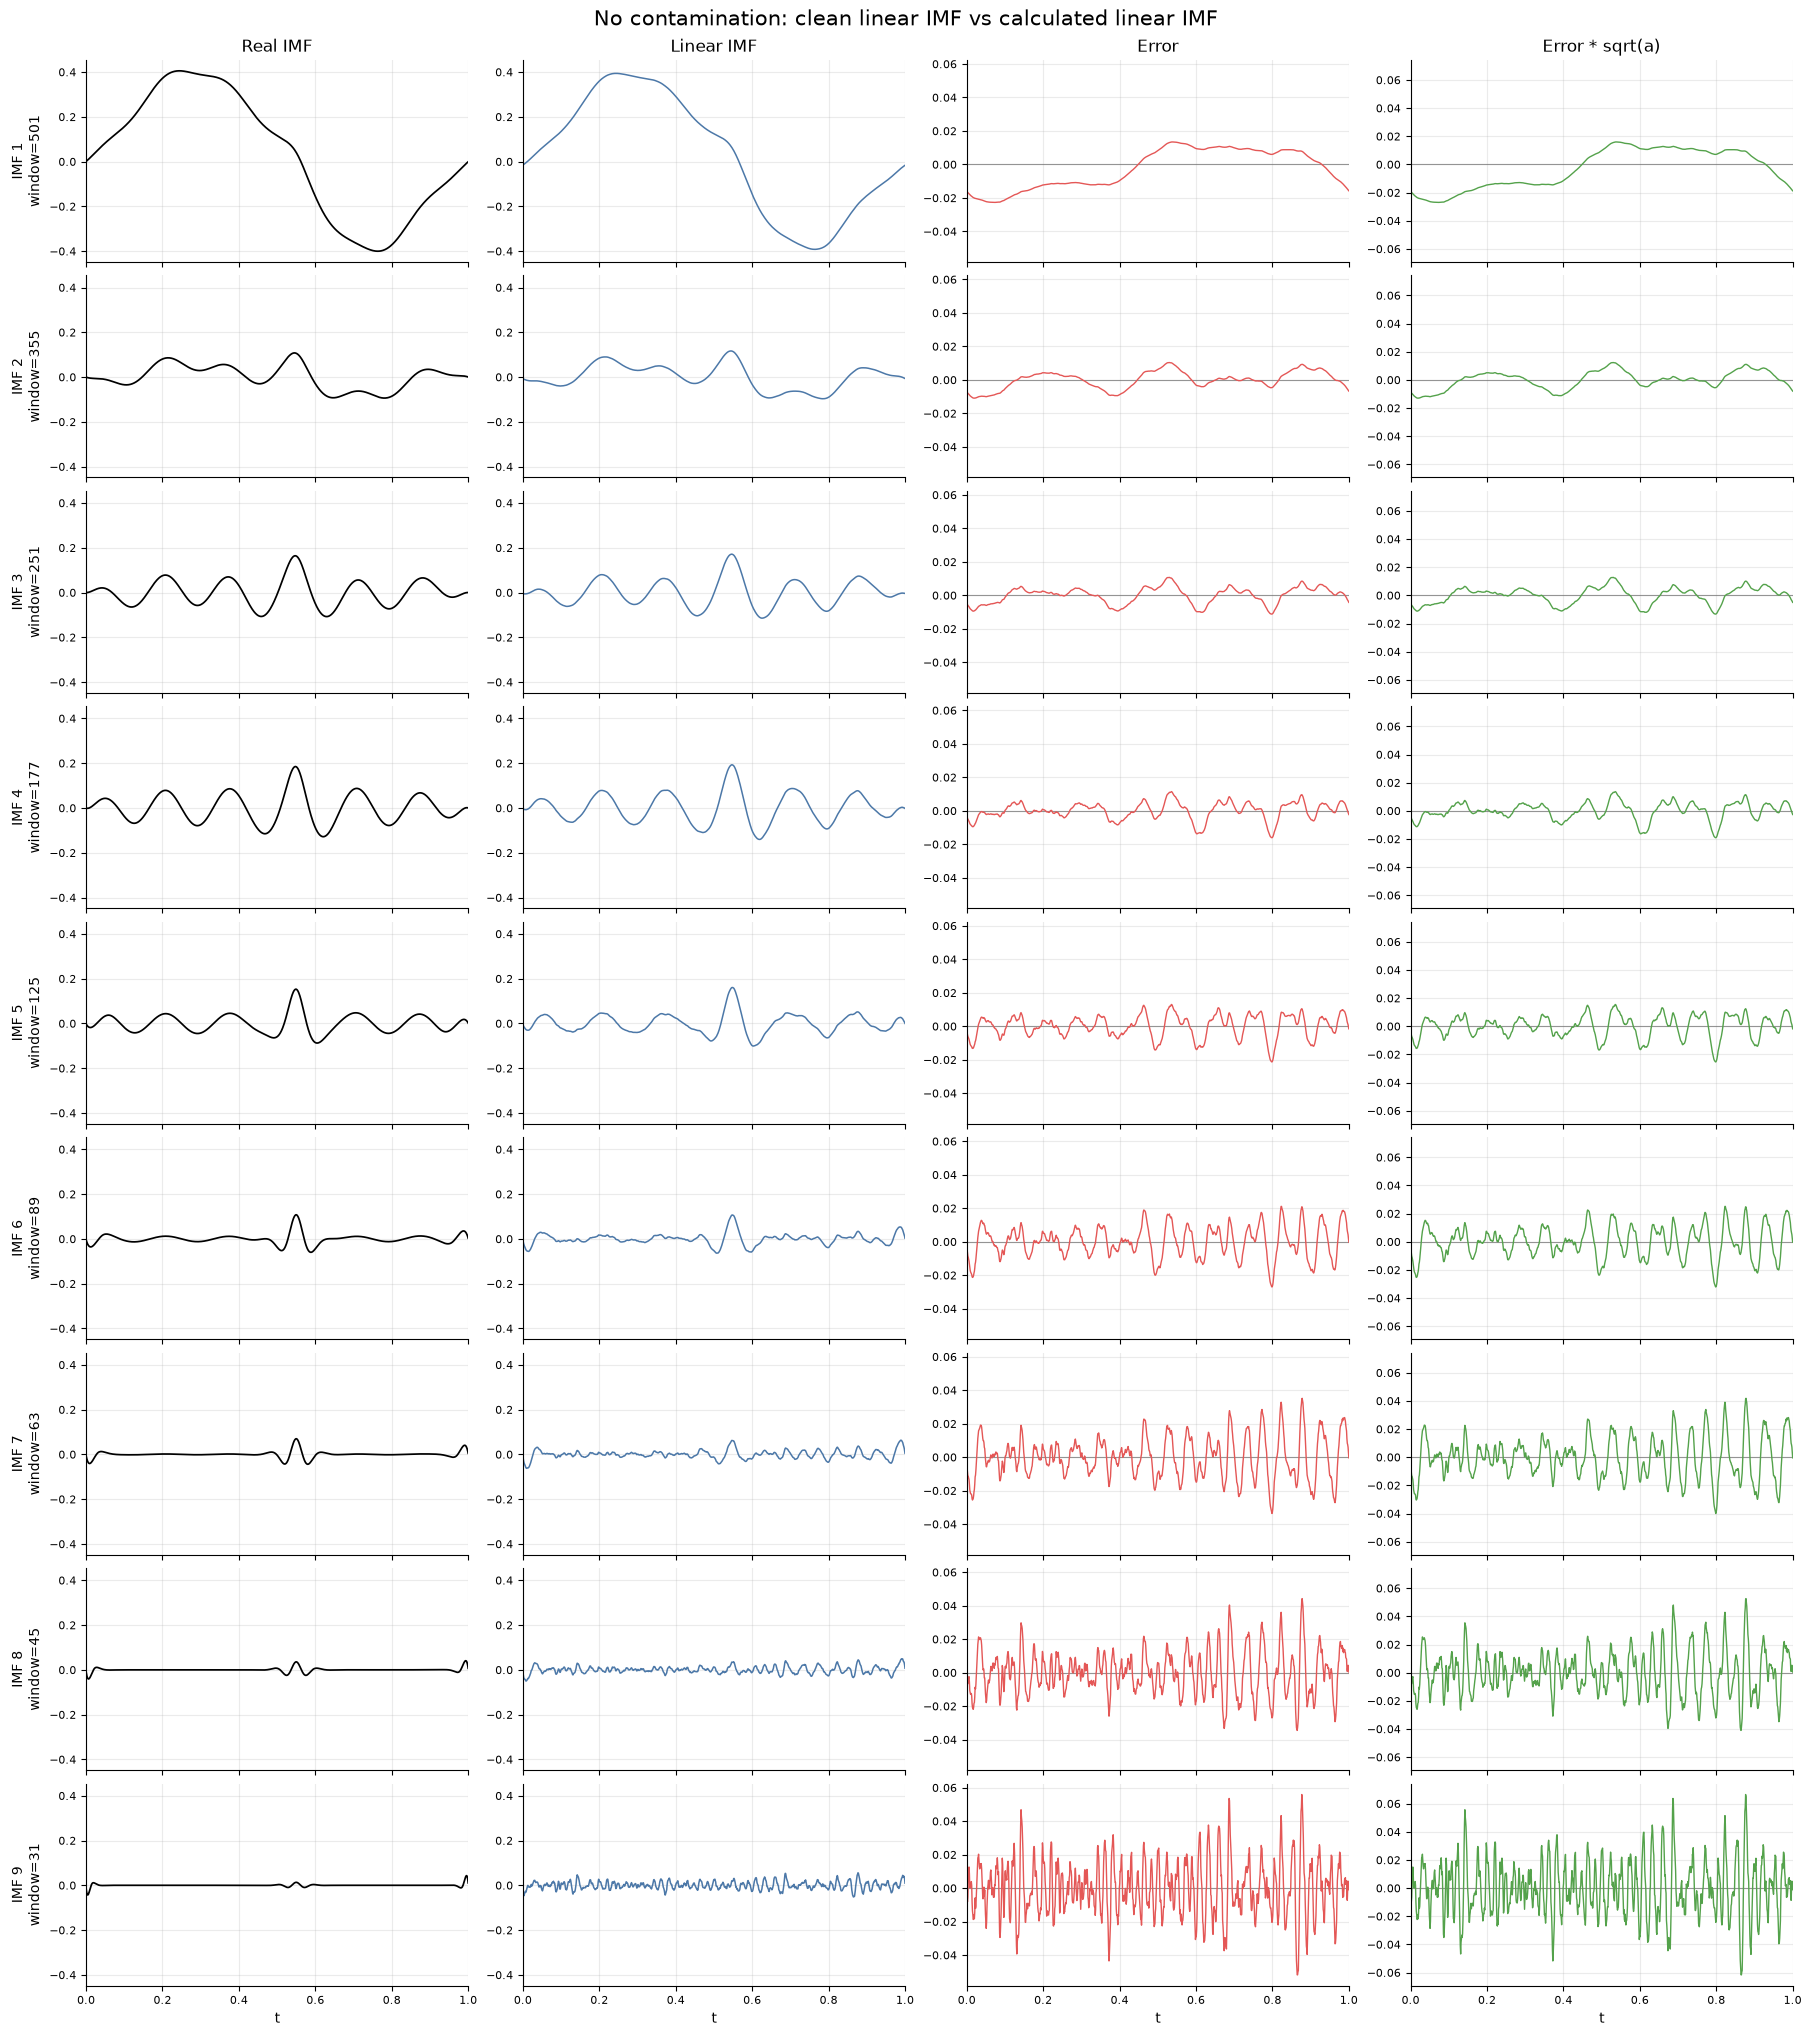

In [69]:
plot_imf_comparison_grid(
    real_linear,
    calculated_linear,
    calculated_label="Linear IMF",
    title="No contamination: clean linear IMF vs calculated linear IMF",
)
plt.show()

### No contamination: error trends

,case,min_stage,metric,slope,intercept
0,no contamination / linear,1,RMSE(error),0.001024,0.004432
1,no contamination / linear,1,RMSE(error * sqrt(a)),0.001218,0.005270


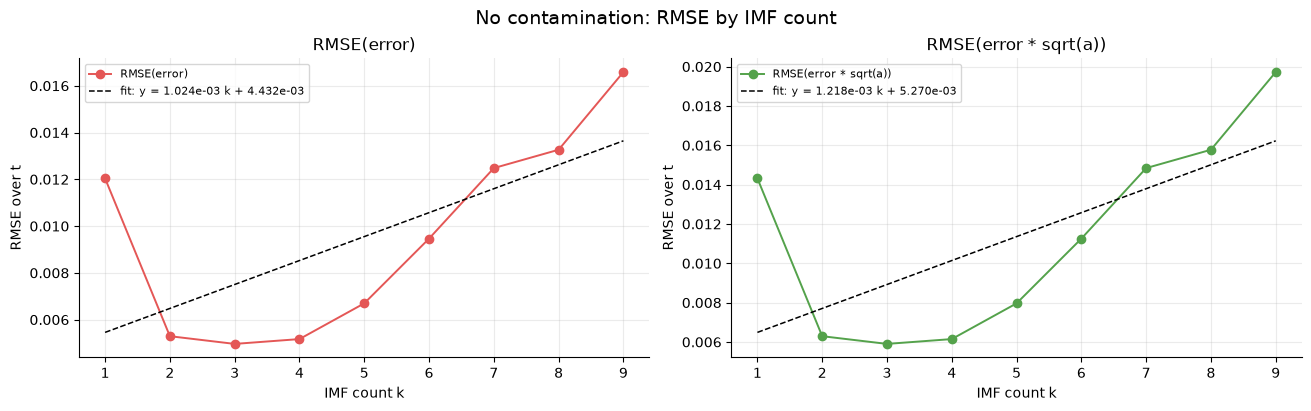

In [70]:
plot_error_trend(
    case_name="no contamination / linear",
    title="No contamination: RMSE by IMF count",
)
plt.show()

### No contamination: error trends without IMF 1

,case,min_stage,metric,slope,intercept
0,no contamination / linear,2,RMSE(error),0.001729,-0.000271
1,no contamination / linear,2,RMSE(error * sqrt(a)),0.002056,-0.000322


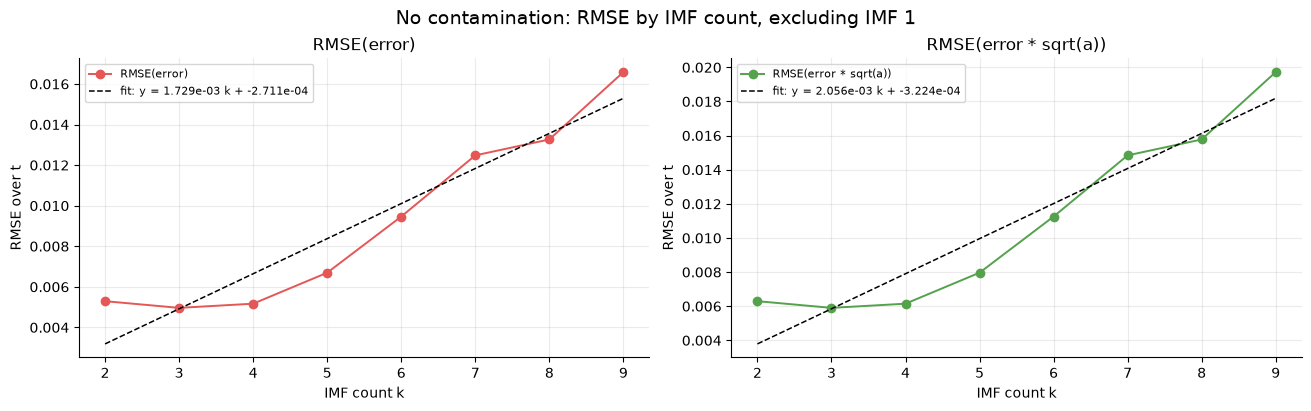

In [71]:
plot_error_trend(
    case_name="no contamination / linear",
    title="No contamination: RMSE by IMF count, excluding IMF 1",
    min_stage=2,
)
plt.show()

### With contamination: robust IMF

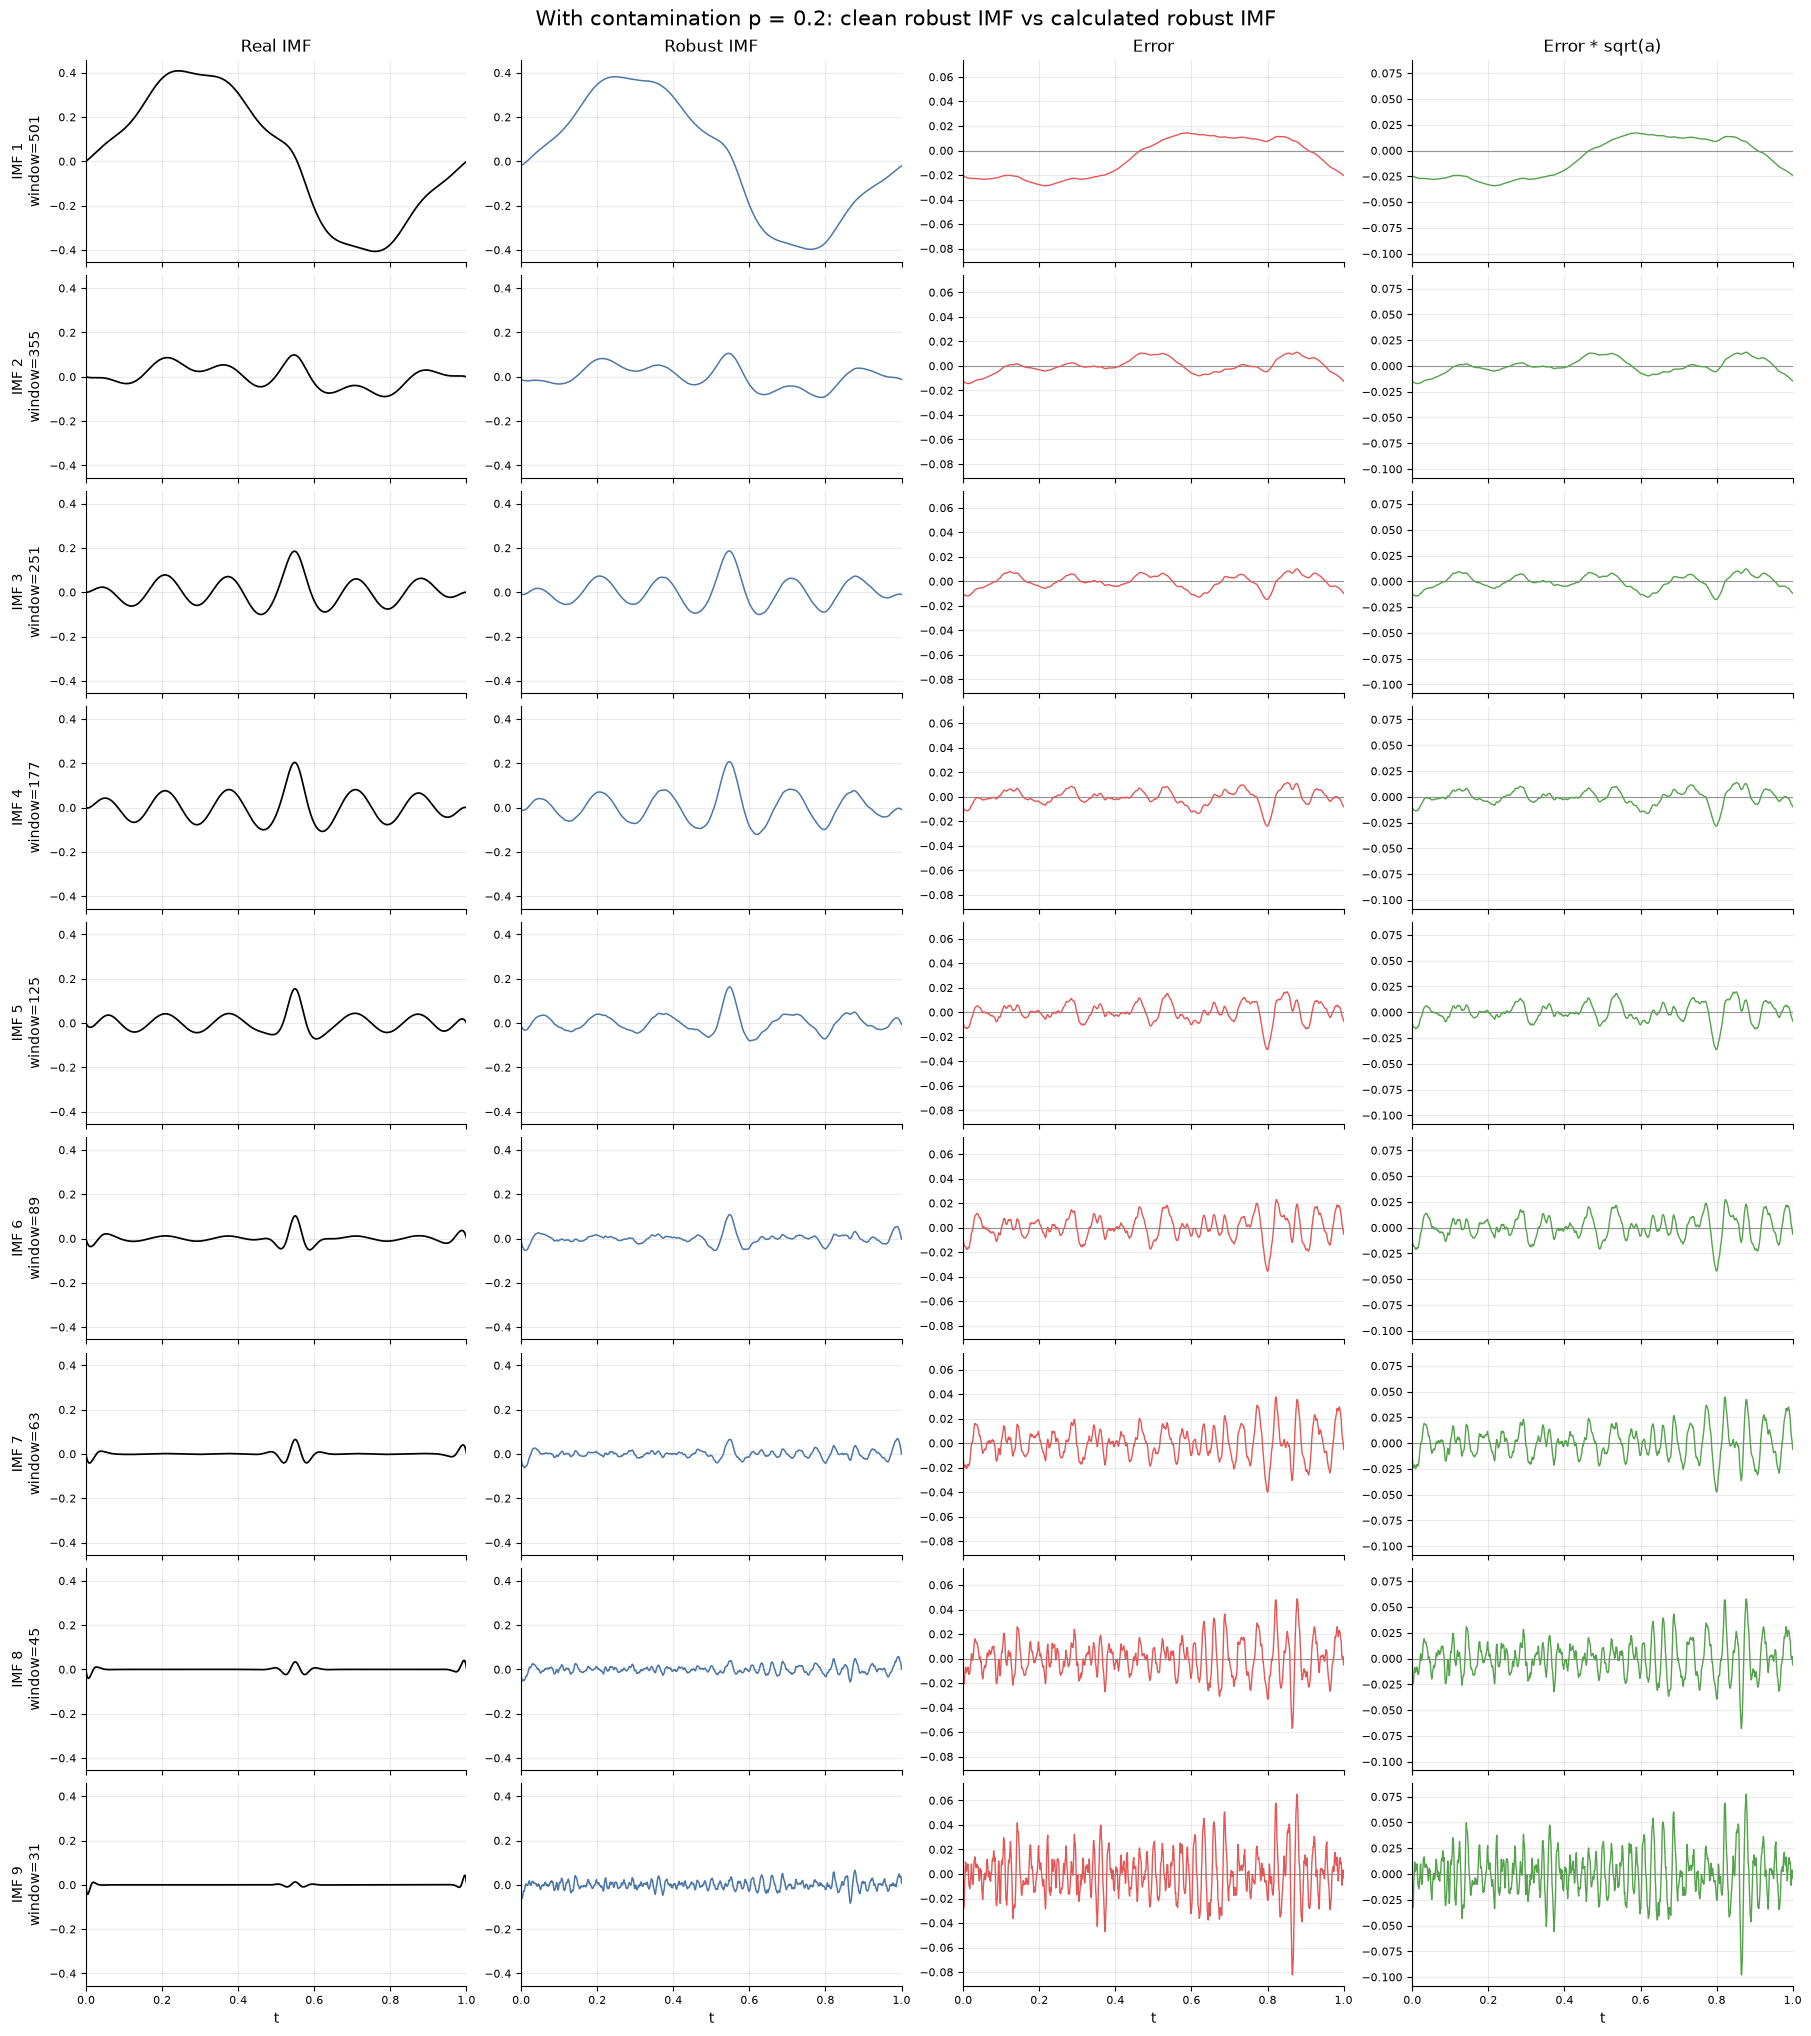

In [72]:
plot_imf_comparison_grid(
    real_robust,
    calculated_robust,
    calculated_label="Robust IMF",
    title="With contamination p = 0.2: clean robust IMF vs calculated robust IMF",
)
plt.show()

### With contamination: error trends

,case,min_stage,metric,slope,intercept
0,p = 0.2 / robust,1,RMSE(error),0.000813,0.006734
1,p = 0.2 / robust,1,RMSE(error * sqrt(a)),0.000967,0.008008


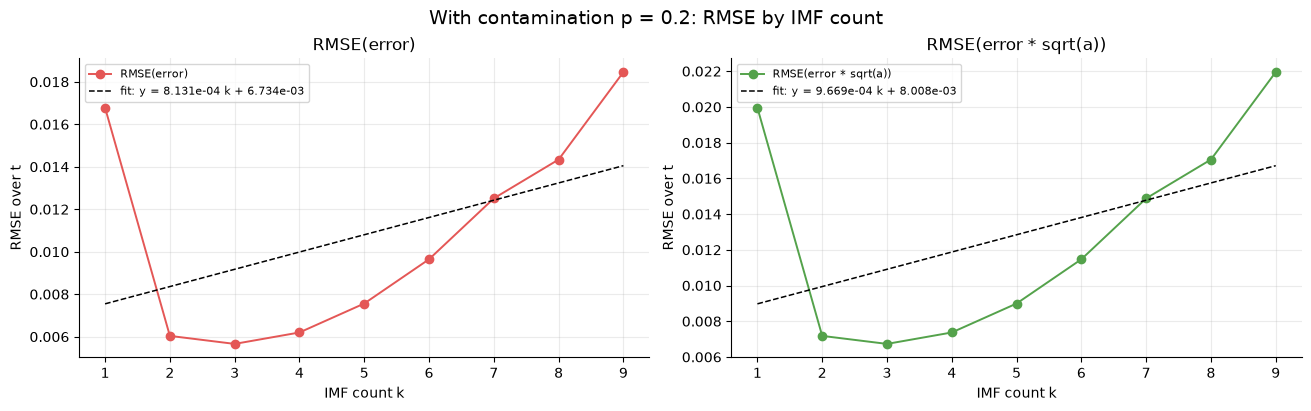

In [73]:
plot_error_trend(
    case_name="p = 0.2 / robust",
    title="With contamination p = 0.2: RMSE by IMF count",
)
plt.show()

### With contamination: error trends without IMF 1

,case,min_stage,metric,slope,intercept
0,p = 0.2 / robust,2,RMSE(error),0.001802,0.000141
1,p = 0.2 / robust,2,RMSE(error * sqrt(a)),0.002143,0.000167


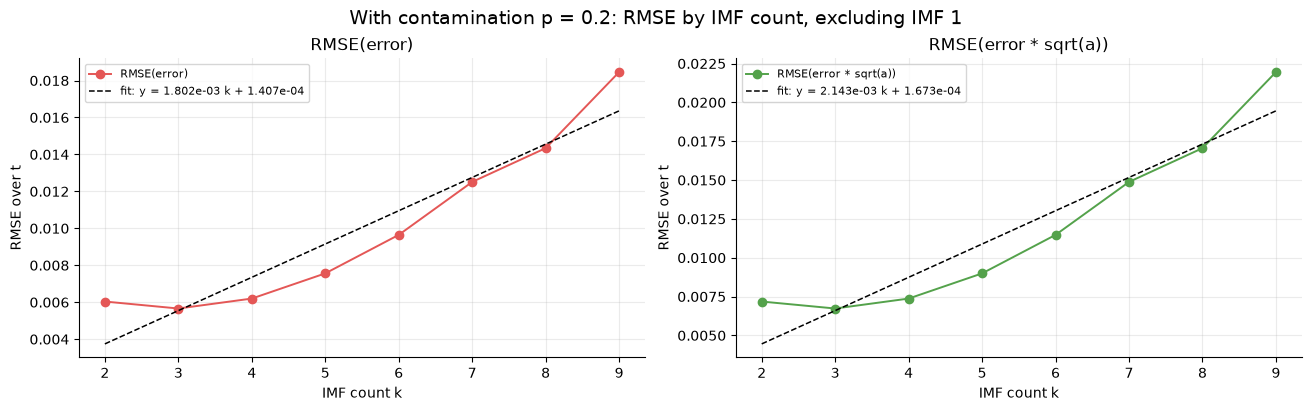

In [74]:
plot_error_trend(
    case_name="p = 0.2 / robust",
    title="With contamination p = 0.2: RMSE by IMF count, excluding IMF 1",
    min_stage=2,
)
plt.show()